## Модели ARIMA: прогноз средней месячной температуры воздуха

Ряд из папки `Series` - средняя месячная температура воздуха за 1920-1939 годы, 240 точек
в градусах Фаренгейта. Задание советует брать ряд с выраженной сезонностью, и здесь она
не только выражена, но и чиста: годовая волна размахом больше двадцати градусов при разбросе
годовых средних меньше градуса и без всякого тренда.

Последние два года ряда откладываются на проверку и в подборе модели не участвуют. Число
разностей выбирается по тестам стационарности и коррелограммам, порядки `p`, `q`, `P`, `Q` -
перебором по информационному критерию Акаике. Качество меряется на отложенном хвосте
в двух режимах - прогноз на два года вперед и прогноз на шаг вперед - и сравнивается
с двумя простыми правилами, которые модель обязана обойти

### Задача 1. Ряд и разделение на обучение и проверку

Прежде чем подбирать модель, надо посмотреть, из чего ряд состоит: цел ли календарь, есть ли
тренд, насколько велика годовая волна на фоне остального разброса. От ответа зависит, что
именно придется дифференцировать.

Разделение делается **по времени**, а не случайно: у временного ряда перемешивание строк само
по себе утечка - модель получила бы в обучение то, что должна предсказать. На проверку уходят
последние 24 месяца, все оценки дальше считаются только по первым 216

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
# фильтр ставится ПОСЛЕ импорта statsmodels: при импорте он прописывает для своих
# предупреждений режим «показывать всегда», и выставленное до него молча перебивается.
# Проверено запуском: с фильтром до импорта kpss печатает InterpolationWarning, после - нет
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('mean-monthly-air-temperature-deg.csv')
ряд = df['Deg'].astype(float)
ряд.index = pd.PeriodIndex(df['Month'], freq='M').to_timestamp()
ряд = ряд.asfreq('MS')

# календарь собирается заново и сверяется с фактическим: пропущенный месяц опаснее
# пропущенного значения - разность соседних точек молча посчитается через дыру
полный = pd.date_range(ряд.index[0], ряд.index[-1], freq='MS')
print('точек %d, с %s по %s' % (len(ряд), ряд.index[0].date(), ряд.index[-1].date()))
print('дыр в календаре %d, пропусков значений %d' % (len(полный) - len(ряд), int(ряд.isna().sum())))
print('минимум %.1f, максимум %.1f, среднее %.2f, разброс %.2f'
      % (ряд.min(), ряд.max(), ряд.mean(), ряд.std(ddof=1)))

обуч, тест = ряд[:-24], ряд[-24:]
print('\nобучение: %d точек, %s - %s' % (len(обуч), обуч.index[0].date(), обуч.index[-1].date()))
print('проверка: %d точек, %s - %s' % (len(тест), тест.index[0].date(), тест.index[-1].date()))

точек 240, с 1920-01-01 по 1939-12-01
дыр в календаре 0, пропусков значений 0
минимум 31.3, максимум 66.5, среднее 49.04, разброс 8.57

обучение: 216 точек, 1920-01-01 - 1937-12-01
проверка: 24 точек, 1938-01-01 - 1939-12-01


In [2]:
# профиль месяца и годовые средние считаются ТОЛЬКО по обучающей части:
# любая оценка по всему ряду занесла бы в модель будущее
профиль = обуч.groupby(обуч.index.month).mean()
годовые = обуч.groupby(обуч.index.year).mean()
рег = stats.linregress(np.arange(len(обуч)), обуч.values)
без_профиля = обуч - обуч.groupby(обуч.index.month).transform('mean')

print('средняя температура по месяцам:', {м: round(з, 1) for м, з in профиль.items()})
print('размах годовой волны %.1f градуса (от месяца %d к месяцу %d)'
      % (профиль.max() - профиль.min(), профиль.idxmin(), профиль.idxmax()))
print('годовые средние: от %.2f в %d году до %.2f в %d, разброс между годами %.2f'
      % (годовые.min(), годовые.idxmin(), годовые.max(), годовые.idxmax(), годовые.std(ddof=1)))
print('наклон прямой по обучению %.5f градуса в месяц, p-value наклона %.3f' % (рег.slope, рег.pvalue))
print('доля дисперсии, которую снимает один профиль месяца: %.3f'
      % (1 - без_профиля.var() / обуч.var()))

внутри_месяца = обуч.groupby(обуч.index.month).std(ddof=1)
print('разброс внутри календарного месяца:', {м: round(з, 2) for м, з in внутри_месяца.items()})
print('от %.2f у месяца %d до %.2f у месяца %d, отношение %.2f'
      % (внутри_месяца.min(), внутри_месяца.idxmin(), внутри_месяца.max(),
         внутри_месяца.idxmax(), внутри_месяца.max() / внутри_месяца.min()))

средняя температура по месяцам: {1: 39.6, 2: 39.0, 3: 41.9, 4: 46.2, 5: 52.6, 6: 58.0, 7: 62.1, 8: 60.5, 9: 56.3, 10: 49.6, 11: 42.1, 12: 39.6}
размах годовой волны 23.1 градуса (от месяца 2 к месяцу 7)
годовые средние: от 47.27 в 1922 году до 50.73 в 1921, разброс между годами 0.90
наклон прямой по обучению 0.00558 градуса в месяц, p-value наклона 0.556
доля дисперсии, которую снимает один профиль месяца: 0.932
разброс внутри календарного месяца: {1: 2.34, 2: 2.78, 3: 2.38, 4: 1.74, 5: 1.77, 6: 2.02, 7: 2.71, 8: 2.58, 9: 2.07, 10: 1.87, 11: 2.17, 12: 3.03}
от 1.74 у месяца 4 до 3.03 у месяца 12, отношение 1.74


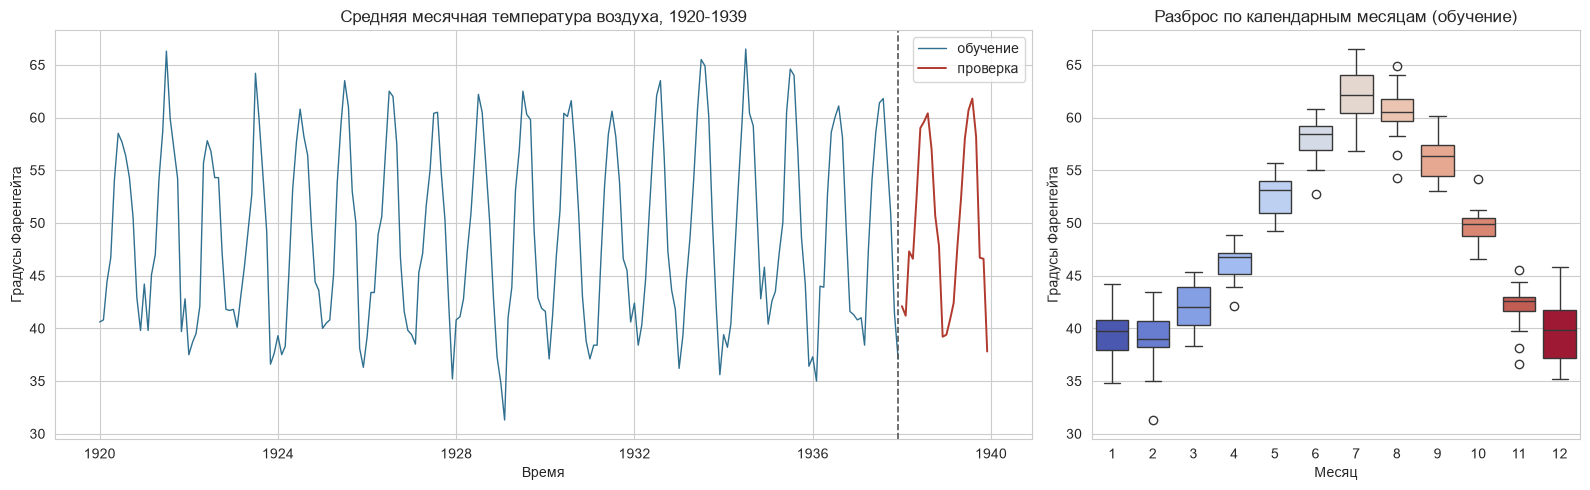

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), width_ratios=[2, 1])

axes[0].plot(обуч.index, обуч.values, color='#2f6f8f', linewidth=1.0, label='обучение')
axes[0].plot(тест.index, тест.values, color='#b03a2e', linewidth=1.4, label='проверка')
axes[0].axvline(обуч.index[-1], color='#555555', linestyle='--', linewidth=1.2)
axes[0].set_title('Средняя месячная температура воздуха, 1920-1939')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Градусы Фаренгейта')
axes[0].legend()

sns.boxplot(x=обуч.index.month, y=обуч.values, ax=axes[1], hue=обуч.index.month,
            palette='coolwarm', legend=False)
axes[1].set_title('Разброс по календарным месяцам (обучение)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Градусы Фаренгейта')

plt.tight_layout()
plt.show()

**Вывод по Задаче 1:**

Ряд целый: **240 месяцев подряд** без дыр в календаре и без пропусков значений, с января 1920
по декабрь 1939 года. Значения от 31.3 до 66.5 - для Цельсия такой размах невозможен, для
Фаренгейта обычен, это примерно от нуля до девятнадцати градусов Цельсия.

**Тренда нет, и это проверено, а не увидено на глаз.** Наклон прямой по обучающей части
**0.006 градуса в месяц при p-value 0.556** - от нуля неотличим. Годовые средние гуляют
от 47.27 до 50.73 при разбросе между годами **0.90 градуса**: климат за двадцать лет
не сдвинулся настолько, чтобы это было заметно.

**Зато годовая волна огромна.** Профиль месяца идет от **39.0 в феврале до 62.1 в июле**,
размах **23.1 градуса**, и один этот профиль объясняет **93.2%** всей дисперсии ряда.

**Разброс внутри месяца при этом почти не зависит от месяца.** Он лежит между **1.74**
у апреля и **3.03** у декабря, отношение крайних значений **1.74** - при том, что сами
средние различаются на 23 градуса. Самые устойчивые месяцы - апрель и май (1.74 и 1.77),
самые изменчивые - декабрь и февраль (3.03 и 2.78).

Значит, вся работа модели - в оставшихся семи процентах: в том, насколько конкретный январь
теплее или холоднее обычного января. Разделение выборок сделано по времени: **216 месяцев**
(1920-1937) на обучение, **24 месяца** (1938-1939) на проверку

### Задача 2. Сколько раз дифференцировать: выбор d и D

У сезонной ARIMA два порядка дифференцирования: обычный `d` и сезонный `D`. Их не подбирают
по информационному критерию вместе с остальными - они отвечают на вопрос о природе ряда,
и решается он тестами стационарности и коррелограммой.

Тест **Дики-Фуллера** ищет единичный корень, то есть накопительный тренд; его нулевая гипотеза -
нестационарность. Тест **KPSS** устроен зеркально, в нулевой гипотезе у него стационарность.
Число лагов в ADF везде выбирается по BIC, а не по AIC: BIC сильнее штрафует лишние
параметры и берет лагов заметно меньше, а каждый лишний лаг стоит одного наблюдения.

Сравним исходный ряд с четырьмя преобразованиями. Заодно проверим признак лишнего
дифференцирования: если разность взята зря, разброс растет, а автокорреляция первого лага
уходит в минус. Величина роста предсказуема - разброс должен умножиться на корень
из 2 * (1 - ACF(1))

In [4]:
def проверка(x, имя):
    """четыре взгляда на стационарность одного ряда: два теста и две автокорреляции"""
    x = pd.Series(x).dropna()
    а = adfuller(x, autolag='BIC')
    # KPSS берет p-value из таблицы и за ее краем возвращает граничное значение, предупреждая
    # об этом. Ловим предупреждение по месту, чтобы в таблице стояло «>0.1», а не выглядящее
    # посчитанным 0.1
    with warnings.catch_warnings(record=True) as поймано:
        warnings.simplefilter('always')
        к = kpss(x, regression='c', nlags='auto')
    за_краем = any('outside of the range' in str(п.message) for п in поймано)
    p_kpss = ('>0.1' if к[1] > 0.05 else '<0.01') if за_краем else '%.4f' % к[1]
    з = acf(x, nlags=13)
    return {'ряд': имя, 'точек': len(x), 'ADF p-value': round(а[1], 4), 'KPSS p-value': p_kpss,
            'ACF(1)': round(з[1], 3), 'ACF(12)': round(з[12], 3), 'разброс': round(x.std(ddof=1), 3)}


варианты = [(обуч, 'исходный ряд'),
            (обуч.diff(12), 'сезонная разность, D=1'),
            (обуч.diff(), 'обычная разность, d=1'),
            (обуч.diff(12).diff(), 'сезонная и обычная вместе'),
            (без_профиля, 'вычитание профиля месяца')]
print(pd.DataFrame([проверка(x, и) for x, и in варианты]).to_string(index=False))

                      ряд  точек  ADF p-value KPSS p-value  ACF(1)  ACF(12)  разброс
             исходный ряд    216       0.0027         >0.1   0.809    0.876    8.653
   сезонная разность, D=1    204       0.0000         >0.1   0.211   -0.624    3.504
    обычная разность, d=1    215       0.0000         >0.1   0.468    0.628    5.274
сезонная и обычная вместе    203       0.0000         >0.1  -0.450   -0.653    4.394
 вычитание профиля месяца    216       0.0000         >0.1   0.270   -0.171    2.264


In [5]:
сезонная = обуч.diff(12).dropna()
двойная = обуч.diff(12).diff().dropna()

# цена сезонной разности: она вычитает из шума этого года шум прошлого года,
# и дисперсия остатка растет предсказуемым образом
acf12 = acf(без_профиля, nlags=12)[12]
print('дисперсия: исходный ряд %.2f, после сезонной разности %.2f, после вычитания профиля %.2f'
      % (обуч.var(), сезонная.var(), без_профиля.var()))
print('отношение дисперсий %.2f, по формуле 2 * (1 - %.3f) = %.2f'
      % (сезонная.var() / без_профиля.var(), acf12, 2 * (1 - acf12)))

# признак лишнего дифференцирования, проверенный формулой
acf1 = acf(сезонная, nlags=1)[1]
print('\nесли к сезонной разности добавить обычную:')
print('   ACF(1) %.3f -> %.3f, разброс %.3f -> %.3f, по формуле %.3f'
      % (acf1, acf(двойная, nlags=1)[1], сезонная.std(ddof=1), двойная.std(ddof=1),
         сезонная.std(ddof=1) * np.sqrt(2 * (1 - acf1))))

дисперсия: исходный ряд 74.88, после сезонной разности 12.28, после вычитания профиля 5.12
отношение дисперсий 2.40, по формуле 2 * (1 - -0.171) = 2.34

если к сезонной разности добавить обычную:
   ACF(1) 0.211 -> -0.450, разброс 3.504 -> 4.394, по формуле 4.401


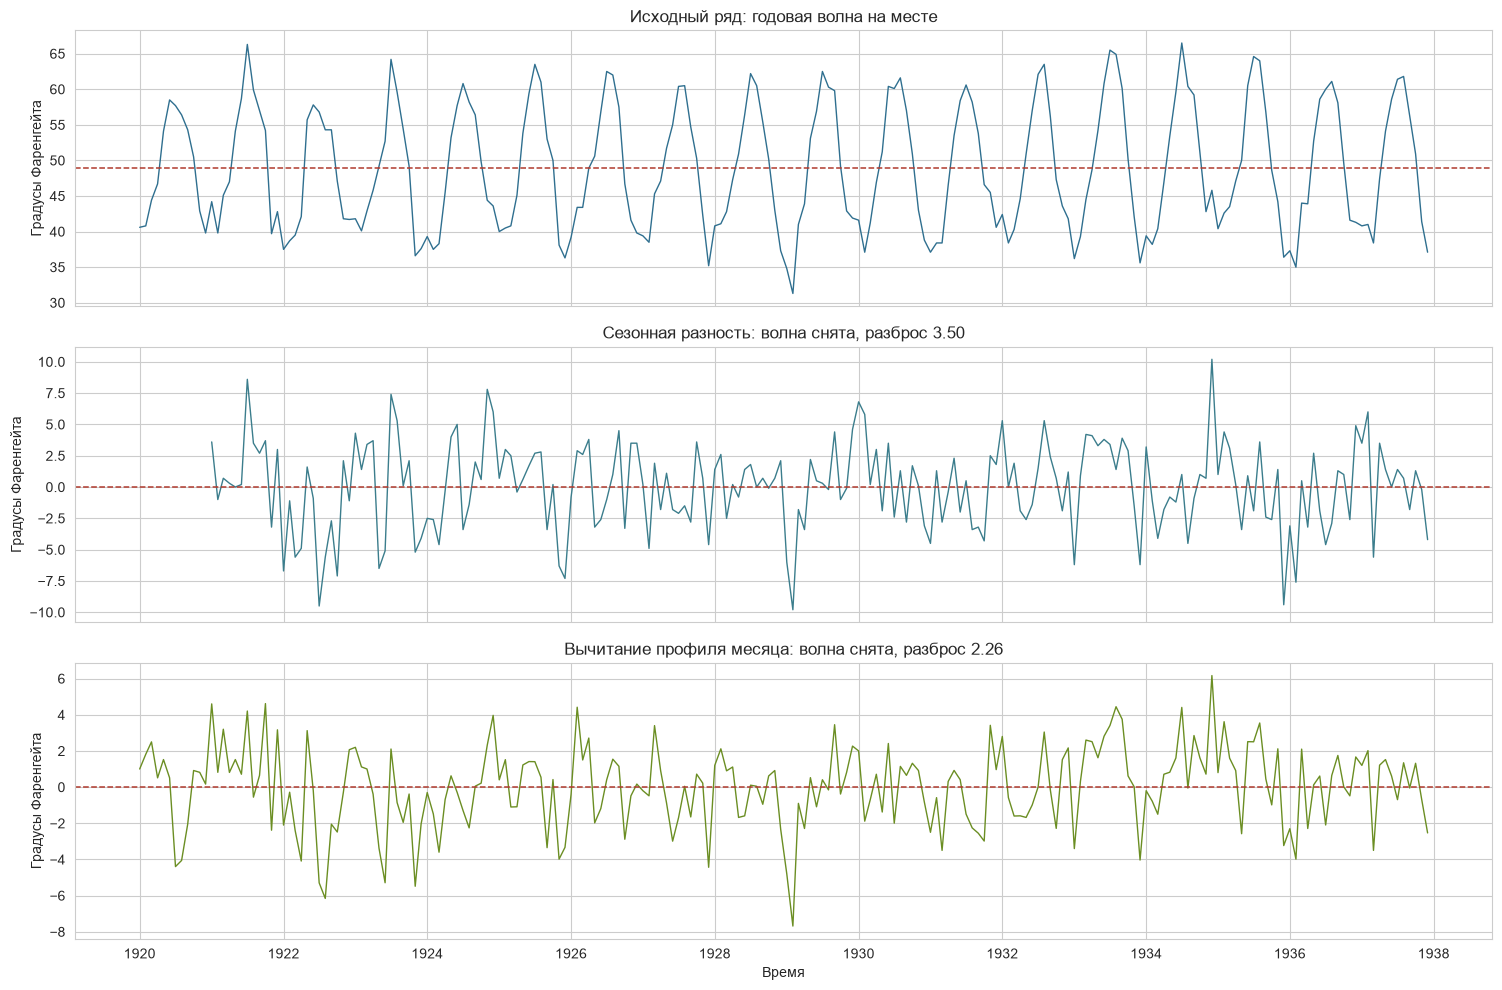

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for ось, (з, подпись, цвет) in zip(axes, [
        (обуч, 'Исходный ряд: годовая волна на месте', '#2f6f8f'),
        (обуч.diff(12), 'Сезонная разность: волна снята, разброс 3.50', '#3b7d8c'),
        (без_профиля, 'Вычитание профиля месяца: волна снята, разброс 2.26', '#6b8e23')]):
    ось.plot(з.index, з.values, color=цвет, linewidth=1.0)
    ось.axhline(з.mean(), color='#b03a2e', linestyle='--', linewidth=1.1)
    ось.set_title(подпись)
    ось.set_ylabel('Градусы Фаренгейта')
axes[-1].set_xlabel('Время')
plt.tight_layout()
plt.show()

**Вывод по Задаче 2:**

**Обычная разность не нужна: d = 0.** Тест Дики-Фуллера на исходном ряде дает p-value
**0.0027** - единичного корня нет, накопительного тренда тоже. Это согласуется с Задачей 1,
где наклон прямой оказался неотличим от нуля.

**Сезонная разность нужна: D = 1.** Формальные тесты этого не показывают: ADF отвергает
единичный корень, а KPSS во всех пяти вариантах упирается в потолок своей таблицы и
возвращает `>0.1` - спорить со стационарностью ему не с чем. Коррелограмма отвечает
сразу: **ACF(12) равен 0.876**.
Температура этого января почти повторяет температуру прошлого января. Ровно тот случай,
ради которого проверки и комбинируют: тест отвечает на свой вопрос, про единичный корень,
и отвечает верно, а годовая волна остается за его пределами.

**Дифференцировать сверх этого нельзя, и это видно по числам.** Сезонная и обычная разность
вместе загоняют ACF(1) из **0.211 в -0.450**, а разброс поднимают с 3.504 до **4.394**.
Формула дает 3.504 * корень из 2 * (1 - 0.211) = **4.401** - совпало до второго знака.
Отрицательная автокорреляция первого лага вместе с выросшим разбросом - подпись лишней
разности.

**У сезонной разности есть цена, и она замерена.** Вычитание профиля месяца дает разброс
**2.264**, сезонная разность - **3.504**, отношение дисперсий **2.40**. Так и должно быть:
разность вычитает из отклонения этого года отклонение прошлого, то есть складывает два
случайных числа вместо одного. По автокорреляции остатка формула предсказывает
2 * (1 - (-0.171)) = **2.34** против замеренных 2.40. Сезонная разность не оценивает
двенадцать средних, но платит за это удвоенным разбросом

### Задача 3. Порядок модели по коррелограммам

Порядки `p` и `q` читаются не по исходному ряду, а по уже приведенному к стационарности:
число взятых разностей - это и есть `d` и `D`, а остальное ищется после них. Правило чтения
такое: у процесса AR(p) частная автокорреляция обрывается после лага `p`, а обычная затухает
плавно; у MA(q) наоборот - обрывается обычная после лага `q`. Если затухают обе, порядок
по картинке не читается и его надо искать перебором.

Значимость считается против доверительной полосы, а не по высоте столбика: полоса
приближенно равна 1.96 / корень из числа точек. Сезонные лаги смотрим отдельно от первых -
всплеск на лаге 12 говорит о сезонной части модели, а не о большом `p`

In [7]:
n = len(сезонная)
полоса = 1.96 / np.sqrt(n)
а_знач = acf(сезонная, nlags=26)
п_знач = pacf(сезонная, nlags=26, method='ywm')

print('точек после сезонной разности %d, доверительная полоса +-%.3f' % (n, полоса))
интересные = [1, 2, 3, 11, 12, 13, 23, 24, 25]
print('лаг:  ' + ''.join('%8d' % l for l in интересные))
print('ACF:  ' + ''.join('%8.3f' % а_знач[l] for l in интересные))
print('PACF: ' + ''.join('%8.3f' % п_знач[l] for l in интересные))
print('\nзначимые лаги ACF: ', [l for l in range(1, 27) if abs(а_знач[l]) > полоса])
print('значимые лаги PACF:', [l for l in range(1, 27) if abs(п_знач[l]) > полоса])

точек после сезонной разности 204, доверительная полоса +-0.137
лаг:         1       2       3      11      12      13      23      24      25
ACF:     0.211   0.141   0.028  -0.153  -0.624  -0.055   0.057   0.219  -0.058
PACF:    0.211   0.101  -0.021  -0.076  -0.595   0.261  -0.081  -0.234   0.064

значимые лаги ACF:  [1, 2, 10, 11, 12, 22, 24]
значимые лаги PACF: [1, 10, 12, 13, 24]


наибольшее расхождение двух методов PACF: 0.0636 на лаге 24 (-0.234 против -0.298)
оба значения за полосой +-0.137, вывод о значимости не меняется


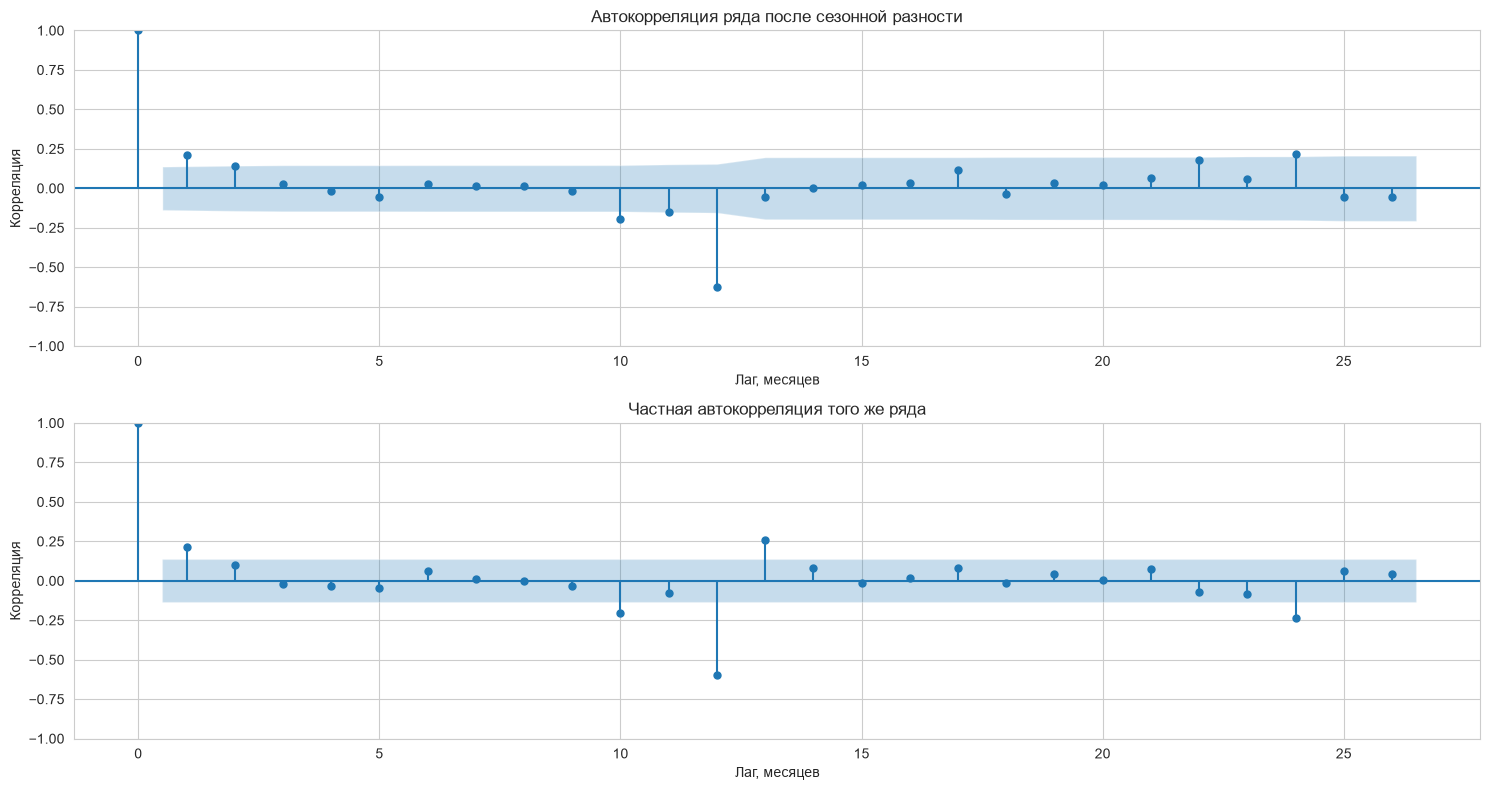

In [8]:
# у pacf и plot_pacf разные умолчания: 'ywadjusted' против 'ywm'. То есть числа
# из таблицы и высоты столбиков на графике считаются немного по-разному, и на коротком
# ряде это стоит проверить, а не считать одинаковым
п_ywadj = pacf(сезонная, nlags=26, method='ywadjusted')
лаг = int(np.argmax(np.abs(п_знач[1:] - п_ywadj[1:]))) + 1
print('наибольшее расхождение двух методов PACF: %.4f на лаге %d (%.3f против %.3f)'
      % (abs(п_знач[лаг] - п_ywadj[лаг]), лаг, п_знач[лаг], п_ywadj[лаг]))
print('оба значения за полосой +-%.3f, вывод о значимости не меняется' % полоса)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
plot_acf(сезонная, lags=26, alpha=0.05, ax=axes[0])
axes[0].set_title('Автокорреляция ряда после сезонной разности')
plot_pacf(сезонная, lags=26, alpha=0.05, ax=axes[1], method='ywm')
axes[1].set_title('Частная автокорреляция того же ряда')
for ось in axes:
    ось.set_xlabel('Лаг, месяцев')
    ось.set_ylabel('Корреляция')
plt.tight_layout()
plt.show()

**Вывод по Задаче 3:**

При 204 точках полоса значимости равна **+-0.137**.

**Сезонная часть читается однозначно, и это MA.** На лаге 12 автокорреляция равна
**-0.624**, а на лаге 24 уже 0.219 - обычная автокорреляция обрывается после первого
сезонного лага. Частная, наоборот, тянется: значима сразу на **12, 13 и 24** лагах
(-0.595, 0.261, -0.234), то есть убывает по модулю, а не обрывается. Это подпись процесса
MA(1) по сезонному лагу, отсюда `P = 0`, `Q = 1`.

**Несезонная часть по картинке не читается.** ACF на первых лагах дает 0.211 и 0.141, PACF -
0.211 и 0.101. Обе затухают, обе едва выходят за полосу, обрыва нет ни у одной. По правилу
это значит, что порядок надо назвать перебором, а не глазом: одинаково подходят и AR(1),
и MA(1), и нулевой порядок.

Кандидат по графикам - **SARIMA(1,0,0)(0,1,1,12)**: сезонная часть прочитана уверенно,
несезонная взята как самый простой из трех равноправных вариантов.

**Два метода PACF дают разные числа, и это проверено.** У `pacf` по умолчанию стоит
`ywadjusted`, у `plot_pacf` - `ywm`, наибольшее расхождение **0.064 на лаге 24**
(-0.234 против -0.298). Оба значения лежат за полосой, так что здесь вывод о значимости
от метода не зависит, но совпадающими эти два счета считать нельзя

### Задача 4. Поиск оптимальных параметров перебором

Оставшиеся порядки - `p`, `q`, `P`, `Q` - по графикам однозначно не читаются, поэтому их ищут
перебором. Критерий отбора - **информационный критерий Акаике**: он складывает меру того,
насколько плохо модель описывает данные, со штрафом за число параметров, и чем он меньше,
тем лучше. Рядом стоит критерий Байеса, который штрафует за лишние параметры сильнее.

Сначала сделаем так, как это делается на лекции: перебором сразу по всем трем порядкам
`p`, `d`, `q`, без сезонной части и без заранее выбранного `d`. Посмотрим, что выберет
критерий, если позволить ему выбирать и число разностей тоже

In [9]:
свободный = []
for p in range(5):
    for d in range(3):
        for q in range(5):
            try:
                м = SARIMAX(обуч, order=(p, d, q), trend='c' if d == 0 else 'n').fit(disp=False, maxiter=500)
                свободный.append({'p': p, 'd': d, 'q': q, 'AIC': round(м.aic, 2),
                                  'логарифм правдоподобия': round(м.llf, 2)})
            except Exception:
                continue

свободный = pd.DataFrame(свободный).sort_values('AIC')
print('перебрано моделей: %d' % len(свободный))
print(свободный.head(6).to_string(index=False))

перебрано моделей: 75
 p  d  q     AIC  логарифм правдоподобия
 3  2  2   12.00                    0.00
 3  0  2 1025.87                 -505.93
 2  0  4 1026.55                 -505.28
 3  1  3 1027.00                 -506.50
 2  0  3 1028.09                 -507.04
 2  1  4 1029.20                 -507.60


In [10]:
# у победителя настолько маленький AIC, что стоит посмотреть на саму модель, а не только
# на число: критерий Акаике складывается из правдоподобия, и у сорвавшейся оптимизации
# правдоподобие может оказаться каким угодно
лучш = свободный.iloc[0]
порядок = (int(лучш.p), int(лучш.d), int(лучш.q))
плохая = SARIMAX(обуч, order=порядок, trend='c' if порядок[1] == 0 else 'n').fit(disp=False, maxiter=500)
прогноз_плохой = плохая.forecast(24)

print('победитель перебора: ARIMA%s' % (порядок,))
print('   логарифм правдоподобия %.4f, оценка дисперсии шума %.3e'
      % (плохая.llf, плохая.params.iloc[-1]))
print('   коэффициенты:', dict(zip(плохая.param_names, np.round(плохая.params.values, 3))))
print('   первые три значения прогноза:', np.round(прогноз_плохой.values[:3], 1).tolist())
print('   RMSE прогноза на отложенных двух годах: %.3g'
      % np.sqrt(np.mean((тест.values - прогноз_плохой.values) ** 2)))

# дело не в том, что модели с разным d считаются по разному числу наблюдений:
# в этой реализации все они дают правдоподобие по одним и тем же 216 точкам
print('\nсколько наблюдений входит в правдоподобие при разном d:')
for d in range(3):
    м = SARIMAX(обуч, order=(1, d, 0), trend='c' if d == 0 else 'n').fit(disp=False, maxiter=500)
    ненулевых = int(np.sum(np.abs(м.filter_results.llf_obs) > 1e-12))
    print('   d = %d: наблюдений %d, ненулевых слагаемых правдоподобия %d, AIC %.2f'
          % (d, м.nobs, ненулевых, м.aic))

победитель перебора: ARIMA(3, 2, 2)
   логарифм правдоподобия 0.0000, оценка дисперсии шума 9.138e+04
   коэффициенты: {'ar.L1': np.float64(1.0), 'ar.L2': np.float64(1.0), 'ar.L3': np.float64(-1.0), 'ma.L1': np.float64(-2.0), 'ma.L2': np.float64(1.0), 'sigma2': np.float64(91378.591)}
   первые три значения прогноза: [-45940165.5, -46577774.6, -47221207.8]
   RMSE прогноза на отложенных двух годах: 5.4e+07

сколько наблюдений входит в правдоподобие при разном d:
   d = 0: наблюдений 216, ненулевых слагаемых правдоподобия 216, AIC 1316.67
   d = 1: наблюдений 216, ненулевых слагаемых правдоподобия 216, AIC 1275.10
   d = 2: наблюдений 216, ненулевых слагаемых правдоподобия 216, AIC 1307.04


Число разностей уже выбрано в Задаче 2 по тестам и коррелограммам: `d = 0`, `D = 1`.
Зафиксируем их и переберем то, ради чего перебор и нужен, - порядки `p`, `q` несезонной
части и `P`, `Q` сезонной

In [11]:
сетка = []
for p in range(4):
    for q in range(4):
        for P in range(3):
            for Q in range(3):
                try:
                    м = SARIMAX(обуч, order=(p, 0, q), seasonal_order=(P, 1, Q, 12),
                                trend='n').fit(disp=False, maxiter=500)
                    сетка.append({'p': p, 'q': q, 'P': P, 'Q': Q,
                                  'AIC': round(м.aic, 2), 'BIC': round(м.bic, 2)})
                except Exception:
                    continue

сетка = pd.DataFrame(сетка)
print('перебрано моделей: %d' % len(сетка))
print('\nлучшие восемь по AIC:')
print(сетка.sort_values('AIC').head(8).to_string(index=False))
print('\nлучшие три по BIC:')
print(сетка.sort_values('BIC').head(3).to_string(index=False))

по_графикам = SARIMAX(обуч, order=(1, 0, 0), seasonal_order=(0, 1, 1, 12),
                      trend='n').fit(disp=False, maxiter=500)
print('\nмодель, прочитанная по графикам в Задаче 3, SARIMA(1,0,0)(0,1,1,12): AIC %.2f, BIC %.2f'
      % (по_графикам.aic, по_графикам.bic))

перебрано моделей: 144

лучшие восемь по AIC:
 p  q  P  Q    AIC    BIC
 2  3  0  2 933.73 960.28
 1  0  2  1 934.96 951.55
 1  0  1  1 935.41 948.68
 1  0  1  2 935.73 952.32
 2  0  2  1 936.02 955.92
 1  1  2  1 936.14 956.05
 0  2  1  1 936.29 952.88
 2  0  1  1 936.31 952.90

лучшие три по BIC:
 p  q  P  Q    AIC    BIC
 1  0  1  1 935.41 948.68
 1  0  2  1 934.96 951.55
 0  1  1  1 939.04 952.31



модель, прочитанная по графикам в Задаче 3, SARIMA(1,0,0)(0,1,1,12): AIC 947.15, BIC 957.10


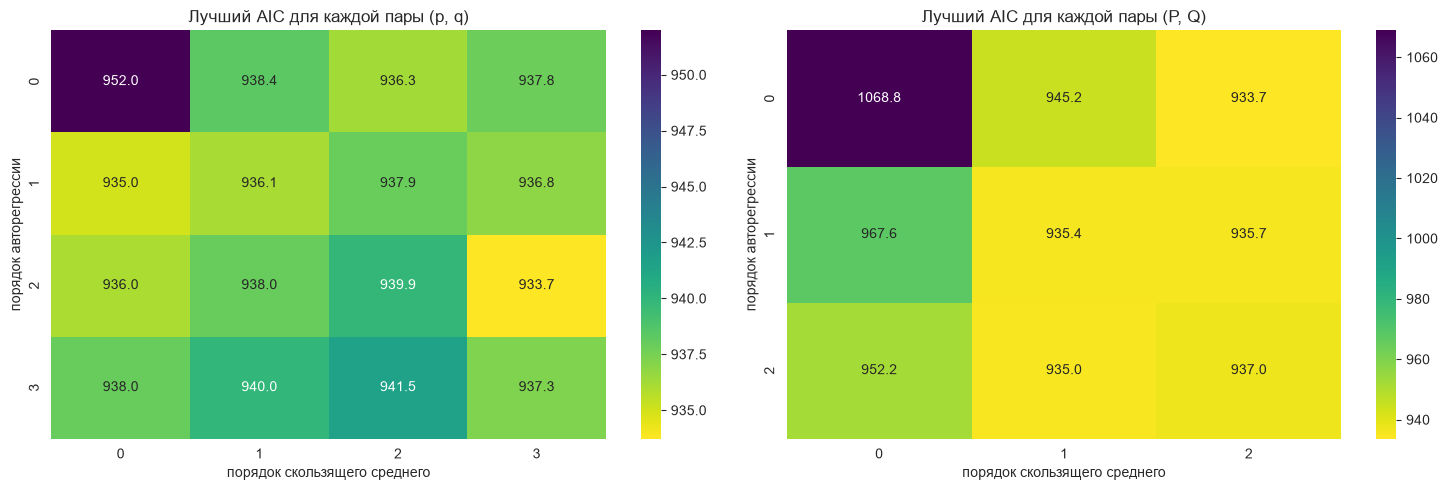

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(сетка.pivot_table(index='p', columns='q', values='AIC', aggfunc='min'),
            annot=True, fmt='.1f', cmap='viridis_r', ax=axes[0])
axes[0].set_title('Лучший AIC для каждой пары (p, q)')
sns.heatmap(сетка.pivot_table(index='P', columns='Q', values='AIC', aggfunc='min'),
            annot=True, fmt='.1f', cmap='viridis_r', ax=axes[1])
axes[1].set_title('Лучший AIC для каждой пары (P, Q)')
for ось in axes:
    ось.set_xlabel('порядок скользящего среднего')
    ось.set_ylabel('порядок авторегрессии')
plt.tight_layout()
plt.show()

**Вывод по Задаче 4:**

**Свободный перебор по трем порядкам дает бессмыслицу, и это видно по самому числу.**
Победителем оказалась ARIMA(3,2,2) с AIC **12.00** при том, что у всех осмысленных моделей
он около тысячи. Логарифм правдоподобия у нее равен ровно **0.0000**, то есть AIC свелся
к удвоенному числу параметров и ни о каком качестве уже не говорит. Коэффициенты стоят
на границе допустимого - **1.0, 1.0, -1.0** у авторегрессии и **-2.0, 1.0** у скользящего
среднего, - оценка дисперсии шума 9.1e+04 при разбросе ряда 8.6, а прогноз на первые три
месяца дает **минус 46 миллионов градусов**. Минимум критерия нашелся не у лучшей модели,
а у сорвавшейся оптимизации.

Дело при этом **не в разном числе наблюдений**: замер показывает, что при `d` = 0, 1 и 2
правдоподобие в этой реализации считается по одним и тем же **216** точкам, и все 216
слагаемых ненулевые. Значит, AIC у таких моделей сопоставим, и сравнивать их между собой
можно - нельзя только брать минимум не глядя.

Лучшая осмысленная модель свободного перебора - **ARIMA(3,0,2) с AIC 1025.87**, и `d` в ней
нулевой. Это тот же ответ, который дали тесты в Задаче 2, но следующие две строки таблицы
идут с `d` = 0 и `d` = 1 вперемешку и отличаются от нее меньше чем на две единицы: сам
по себе перебор такой ответ не выделяет.

**С зафиксированными d = 0 и D = 1 перебор из 144 моделей снижает AIC на 92 единицы.**
Минимум у **SARIMA(2,0,3)(0,1,2,12)**, AIC **933.73** против 1025.87 у лучшей несезонной.
Критерий Байеса выбирает более скромную
**SARIMA(1,0,0)(1,1,1,12)** с BIC **948.68** - и это обычное расхождение двух критериев,
байесовский сильнее штрафует лишние параметры.

**Верхушка таблицы почти не различается:** от первой модели до восьмой - **2.6 единицы AIC**,
а прочитанная по графикам SARIMA(1,0,0)(0,1,1,12) отстает на 13.4.

**Тепловые карты показывают, что решает сезонная часть, а не несезонная.** По парам `(p, q)`
лучший AIC лежит между **933.7 и 952.0**, и весь этот размах создает одна клетка `(0, 0)` -
модель, у которой несезонной части нет вовсе; все остальные одиннадцать клеток укладываются
в восемь единиц. По парам `(P, Q)` размах **135 единиц**: без сезонных членов, при уже взятой
сезонной разности, AIC равен **1068.8**, а один сезонный член скользящего среднего снижает
его сразу до 945.2. Порядок `Q = 1` выигрывает у `Q = 0` при любом `P` - от 17 до 124 единиц

### Задача 5. Прогноз на отложенные два года

Критерий Акаике меряет, насколько хорошо модель описывает то, что уже видела. Настоящая
проверка - отложенный хвост, который в подборе не участвовал.

Прогноз считается в двух режимах. **На два года вперед** - модель один раз смотрит на
обучающую часть и выдает 24 месяца сразу, не получая по дороге ни одного факта. **На шаг
вперед** - после каждого месяца модель узнает, что случилось на самом деле, но не
переобучается. Первый режим отвечает на вопрос «какой будет погода в 1939 году», второй -
«насколько точно можно назвать следующий месяц».

Сравнивать модель надо не с нулем, а с тем, что можно сделать без нее. Два простых правила:
повторить прошлый год как есть и взять среднюю температуру этого месяца за все годы обучения

In [13]:
def подгонка(данные, порядок, сезонный=(0, 0, 0, 0), экз=None):
    """одна точка входа для всех моделей работы: свободный член нужен только там,
    где ряд не дифференцируется"""
    тренд = 'n' if (порядок[1] or сезонный[1]) else 'c'
    return SARIMAX(данные, exog=экз, order=порядок, seasonal_order=сезонный,
                   trend=тренд).fit(disp=False, maxiter=500)


def на_шаг(результат, факты, экз=None):
    """прогноз на шаг вперед: модель каждый месяц получает предыдущий факт, но не переобучается"""
    return результат.append(факты, exog=экз, refit=False).fittedvalues.loc[факты.index].values


def rmse(факт, прогноз):
    return float(np.sqrt(np.mean((np.asarray(факт) - np.asarray(прогноз)) ** 2)))


кандидаты = [('SARIMA(2,0,3)(0,1,2,12), лучшая по AIC', (2, 0, 3), (0, 1, 2, 12)),
             ('SARIMA(1,0,0)(1,1,1,12), лучшая по BIC', (1, 0, 0), (1, 1, 1, 12)),
             ('SARIMA(1,0,0)(0,1,1,12), по графикам', (1, 0, 0), (0, 1, 1, 12)),
             ('ARIMA(3,0,2), без сезонной части', (3, 0, 2), (0, 0, 0, 0))]

модели, сводка = {}, []
for имя, порядок, сезонный in кандидаты:
    м = подгонка(обуч, порядок, сезонный)
    п24, п1 = м.forecast(24), на_шаг(м, тест)
    модели[имя] = (м, п24.values, п1)
    сводка.append({'модель': имя, 'AIC': round(м.aic, 2), 'BIC': round(м.bic, 2),
                   'RMSE на 24 шага': round(rmse(тест, п24), 3),
                   'MAE на 24 шага': round(mean_absolute_error(тест, п24), 3),
                   'RMSE на шаг': round(rmse(тест, п1), 3),
                   'MAE на шаг': round(mean_absolute_error(тест, п1), 3)})

# базовые правила: повтор последнего года обучения и средняя температура календарного месяца
повтор = np.tile(обуч[-12:].values, 2)
по_профилю = профиль.loc[тест.index.month].values
повтор_на_шаг = ряд.shift(12).loc[тест.index].values
сводка.append({'модель': 'база: повтор последнего года', 'AIC': np.nan, 'BIC': np.nan,
               'RMSE на 24 шага': round(rmse(тест, повтор), 3),
               'MAE на 24 шага': round(mean_absolute_error(тест, повтор), 3),
               'RMSE на шаг': round(rmse(тест, повтор_на_шаг), 3),
               'MAE на шаг': round(mean_absolute_error(тест, повтор_на_шаг), 3)})
сводка.append({'модель': 'база: средний месяц по обучению', 'AIC': np.nan, 'BIC': np.nan,
               'RMSE на 24 шага': round(rmse(тест, по_профилю), 3),
               'MAE на 24 шага': round(mean_absolute_error(тест, по_профилю), 3),
               'RMSE на шаг': round(rmse(тест, по_профилю), 3),
               'MAE на шаг': round(mean_absolute_error(тест, по_профилю), 3)})

print(pd.DataFrame(сводка).to_string(index=False))

                                модель     AIC     BIC  RMSE на 24 шага  MAE на 24 шага  RMSE на шаг  MAE на шаг
SARIMA(2,0,3)(0,1,2,12), лучшая по AIC  933.73  960.28            2.263           1.744        2.212       1.820
SARIMA(1,0,0)(1,1,1,12), лучшая по BIC  935.41  948.68            2.337           1.791        2.364       1.827
  SARIMA(1,0,0)(0,1,1,12), по графикам  947.15  957.10            2.333           1.694        2.319       1.767
      ARIMA(3,0,2), без сезонной части 1025.87 1049.49            2.531           1.843        2.454       1.852
          база: повтор последнего года     NaN     NaN            2.932           1.950        2.840       1.929
       база: средний месяц по обучению     NaN     NaN            2.311           1.684        2.311       1.684


In [14]:
лучшая_имя = кандидаты[0][0]
лучшая, прогноз24, прогноз1 = модели[лучшая_имя]
print('параметры лучшей модели:')
print(pd.Series(лучшая.params.values, index=лучшая.param_names).round(3).to_string())

# разница в четвертом знаке ничего не стоит, если она в пределах шума:
# сравниваем модель с базой парно, на одних и тех же 24 месяцах
ошибка_модели = np.abs(тест.values - прогноз24)
ошибка_базы = np.abs(тест.values - по_профилю)
критерий = stats.wilcoxon(ошибка_модели, ошибка_базы)
print('\nсредняя абсолютная ошибка: модель %.3f, база %.3f' % (ошибка_модели.mean(), ошибка_базы.mean()))
print('модель точнее базы в %d месяцах из 24, критерий Уилкоксона p-value %.3f'
      % (int((ошибка_модели < ошибка_базы).sum()), критерий.pvalue))

рнг = np.random.default_rng(10)
разности = []
for _ in range(2000):
    i = рнг.integers(0, 24, 24)
    разности.append(rmse(тест.values[i], прогноз24[i]) - rmse(тест.values[i], по_профилю[i]))
низ, верх = np.percentile(разности, [2.5, 97.5])
print('бутстрэп разности RMSE (модель минус база): среднее %.3f, интервал 95%% [%.3f, %.3f]'
      % (np.mean(разности), низ, верх))

интервал = лучшая.get_forecast(24).conf_int(alpha=0.05)
внутри = ((тест.values >= интервал.iloc[:, 0].values) & (тест.values <= интервал.iloc[:, 1].values)).sum()
print('фактов внутри 95%%-интервала прогноза: %d из 24, средняя ширина интервала %.2f градуса'
      % (внутри, (интервал.iloc[:, 1] - интервал.iloc[:, 0]).mean()))

параметры лучшей модели:
ar.L1       1.061
ar.L2      -0.957
ma.L1      -0.849
ma.L2       0.842
ma.L3       0.157
ma.S.L12   -1.045
ma.S.L24    0.268
sigma2      4.698

средняя абсолютная ошибка: модель 1.744, база 1.684
модель точнее базы в 11 месяцах из 24, критерий Уилкоксона p-value 0.726
бутстрэп разности RMSE (модель минус база): среднее -0.026, интервал 95% [-0.387, 0.379]
фактов внутри 95%-интервала прогноза: 22 из 24, средняя ширина интервала 8.94 градуса


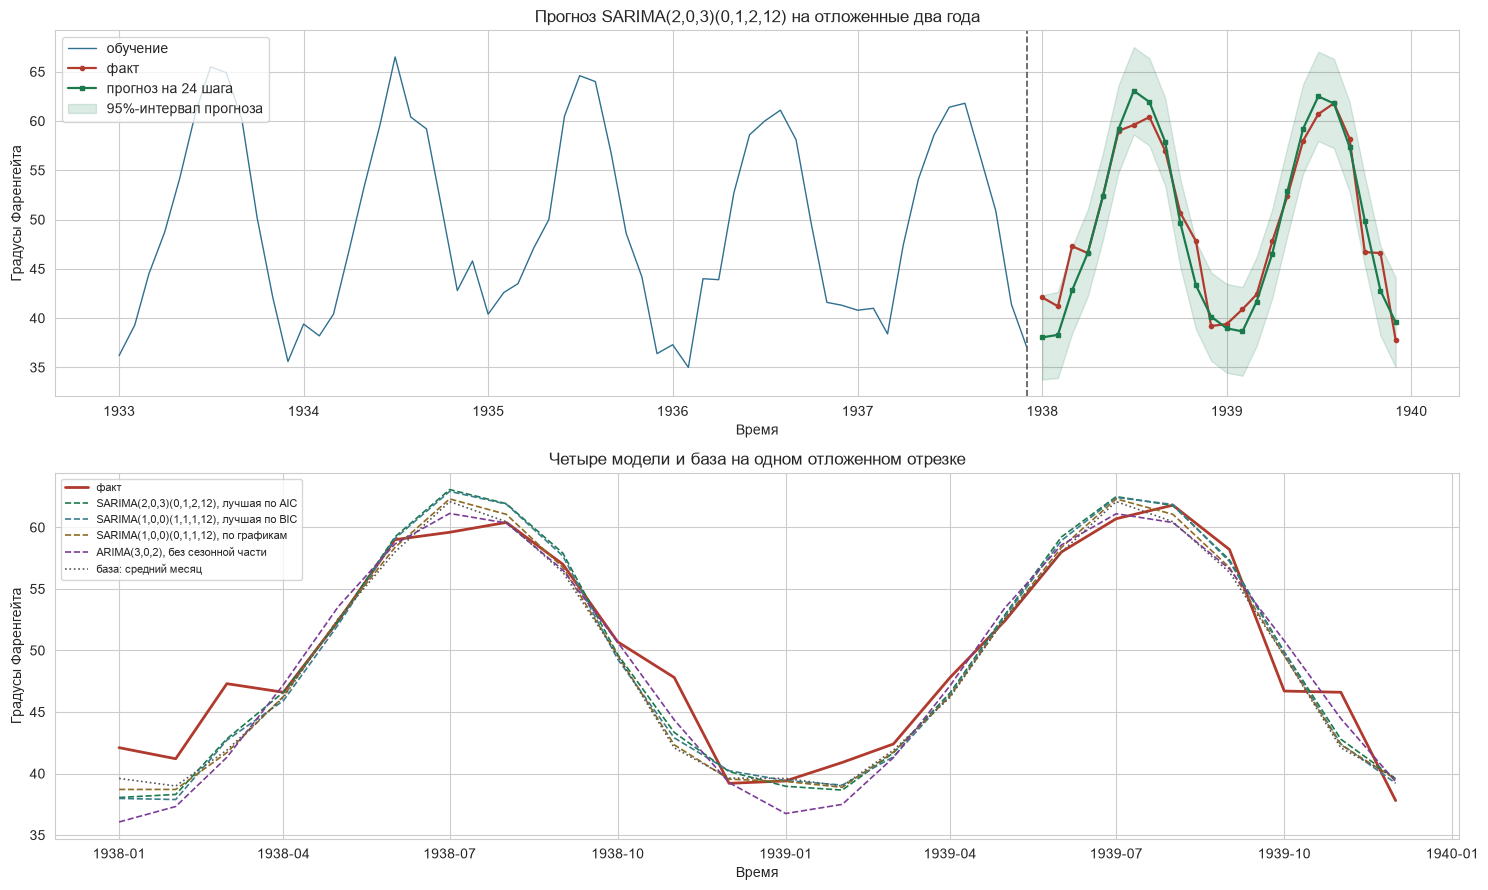

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

хвост = обуч[-60:]
axes[0].plot(хвост.index, хвост.values, color='#2f6f8f', linewidth=1.0, label='обучение')
axes[0].plot(тест.index, тест.values, color='#b03a2e', linewidth=1.6, marker='o',
             markersize=3, label='факт')
axes[0].plot(тест.index, прогноз24, color='#1a7a4c', linewidth=1.6, marker='s',
             markersize=3, label='прогноз на 24 шага')
axes[0].fill_between(тест.index, интервал.iloc[:, 0], интервал.iloc[:, 1],
                     color='#1a7a4c', alpha=0.15, label='95%-интервал прогноза')
axes[0].axvline(обуч.index[-1], color='#555555', linestyle='--', linewidth=1.2)
axes[0].set_title('Прогноз SARIMA(2,0,3)(0,1,2,12) на отложенные два года')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Градусы Фаренгейта')
axes[0].legend(loc='upper left')

axes[1].plot(тест.index, тест.values, color='#b03a2e', linewidth=2.0, label='факт')
for имя, цвет in zip([к[0] for к in кандидаты], ['#1a7a4c', '#3b7d8c', '#8e6b23', '#7d3c98']):
    axes[1].plot(тест.index, модели[имя][1], linewidth=1.2, linestyle='--', color=цвет, label=имя)
axes[1].plot(тест.index, по_профилю, color='#555555', linewidth=1.2, linestyle=':',
             label='база: средний месяц')
axes[1].set_title('Четыре модели и база на одном отложенном отрезке')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Градусы Фаренгейта')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

**Вывод по Задаче 5:**

**Сезонная часть решает все.** Несезонная ARIMA(3,0,2), лучшая в свободном переборе, дает
на двух годах RMSE **2.531** и проигрывает даже среднему месяцу. Три сезонные модели идут
плотно: **2.263**, 2.333 и 2.337. Повтор прошлого года - худшее из всего, **2.932**:
он тащит в прогноз погодные отклонения одного конкретного года.

**А вот выигрыша над средним месяцем нет.** База «средняя температура этого месяца
за 18 лет» дает **2.311** против **2.263** у лучшей модели - разница **0.048 градуса**,
то есть два процента. Проверка показывает, что этой разницы не существует:

*   **Парное сравнение.** Модель точнее базы в **11 месяцах из 24**, критерий Уилкоксона
    дает p-value **0.726**.
*   **Бутстрэп по месяцам.** Разность RMSE в среднем **-0.026** с интервалом
    **[-0.387, 0.379]** - ноль лежит внутри с большим запасом.

Это не провал модели, а свойство ряда: в Задаче 1 замерено, что профиль месяца снимает 93.2%
дисперсии, и на долю всего остального остается около семи процентов. Обогнать среднее
на такой задаче почти нечем.

**Что модель дает сверх базы - это интервал.** Из 24 фактов **22 попали в 95%-полосу**
при ее средней ширине 8.94 градуса; ожидалось около 22.8. Среднее правило никакой полосы
не строит вообще.

**В режиме «на шаг вперед» картина та же:** 2.212 у лучшей модели против 2.311 у базы.
Знание предыдущего месяца дает выигрыш **0.051 градуса** против прогноза на два года -
и большего ждать неоткуда: у отклонений от профиля автокорреляция первого лага равна
**0.270** (замерено в Задаче 2), то есть память ряда короткая и слабая

### Задача 6. График остатков предсказания ряда

Если модель забрала из ряда всю структуру, в остатке должен лежать белый шум: без
автокорреляции, с постоянным разбросом и без выделяющихся хвостов. Все, что осталось
в остатке закономерного, - это то, что модель не описала.

Смотрим на четыре вещи сразу: сами остатки во времени, их автокорреляцию, распределение
и квантильный график против нормального. Численно то же самое проверяют критерий
**Льюнга-Бокса** (нулевая гипотеза - автокорреляции нет) и критерий **Шапиро-Уилка**
(нулевая гипотеза - распределение нормально).

Первые тринадцать остатков отбрасываются: пока не набралось двенадцать месяцев истории,
сезонная часть модели работает вхолостую и остатки там огромны по построению

In [16]:
остатки = лучшая.resid[13:]
полоса_ост = 1.96 / np.sqrt(len(остатки))
акф_ост = acf(остатки, nlags=24)
значимые = [l for l in range(1, 25) if abs(акф_ост[l]) > полоса_ост]

print('остатки обучения: среднее %.3f, разброс %.3f, асимметрия %.3f, эксцесс %.3f'
      % (остатки.mean(), остатки.std(ddof=1), stats.skew(остатки), stats.kurtosis(остатки)))
print('значимых лагов автокорреляции: %d из 24 при полосе +-%.3f %s'
      % (len(значимые), полоса_ост, значимые))
print('\nкритерий Льюнга-Бокса:')
print(acorr_ljungbox(остатки, lags=[6, 12, 24], return_df=True).round(4).to_string())
шапиро = stats.shapiro(остатки)
print('\nкритерий Шапиро-Уилка: статистика %.4f, p-value %.4f' % (шапиро.statistic, шапиро.pvalue))

# постоянство разброса на глаз по графику не проверить: режем остатки на четыре куска
# и сравниваем разбросы критерием Левене
куски = np.array_split(остатки.values, 4)
левене = stats.levene(*куски)
print('\nразбросы по четвертям:', [round(float(к.std(ddof=1)), 3) for к in куски])
print('средние по четвертям: ', [round(float(к.mean()), 3) for к in куски])
print('критерий Левене: статистика %.3f, p-value %.3f' % (левене.statistic, левене.pvalue))

ошибки = тест.values - прогноз24
print('\nошибки прогноза на отложенных двух годах: среднее %.3f, разброс %.3f'
      % (ошибки.mean(), ошибки.std(ddof=1)))
print('самая большая ошибка %.2f градуса, месяц %s'
      % (ошибки[np.argmax(np.abs(ошибки))], тест.index[np.argmax(np.abs(ошибки))].strftime('%Y-%m')))

остатки обучения: среднее 0.034, разброс 2.339, асимметрия -0.033, эксцесс 0.334
значимых лагов автокорреляции: 0 из 24 при полосе +-0.138 []

критерий Льюнга-Бокса:
    lb_stat  lb_pvalue
6    7.1282     0.3092
12   9.3795     0.6702
24  20.4865     0.6688

критерий Шапиро-Уилка: статистика 0.9933, p-value 0.4874

разбросы по четвертям: [2.759, 2.307, 1.999, 2.144]
средние по четвертям:  [-0.549, -0.053, 0.565, 0.177]
критерий Левене: статистика 1.106, p-value 0.348

ошибки прогноза на отложенных двух годах: среднее 0.447, разброс 2.267
самая большая ошибка 4.49 градуса, месяц 1938-03


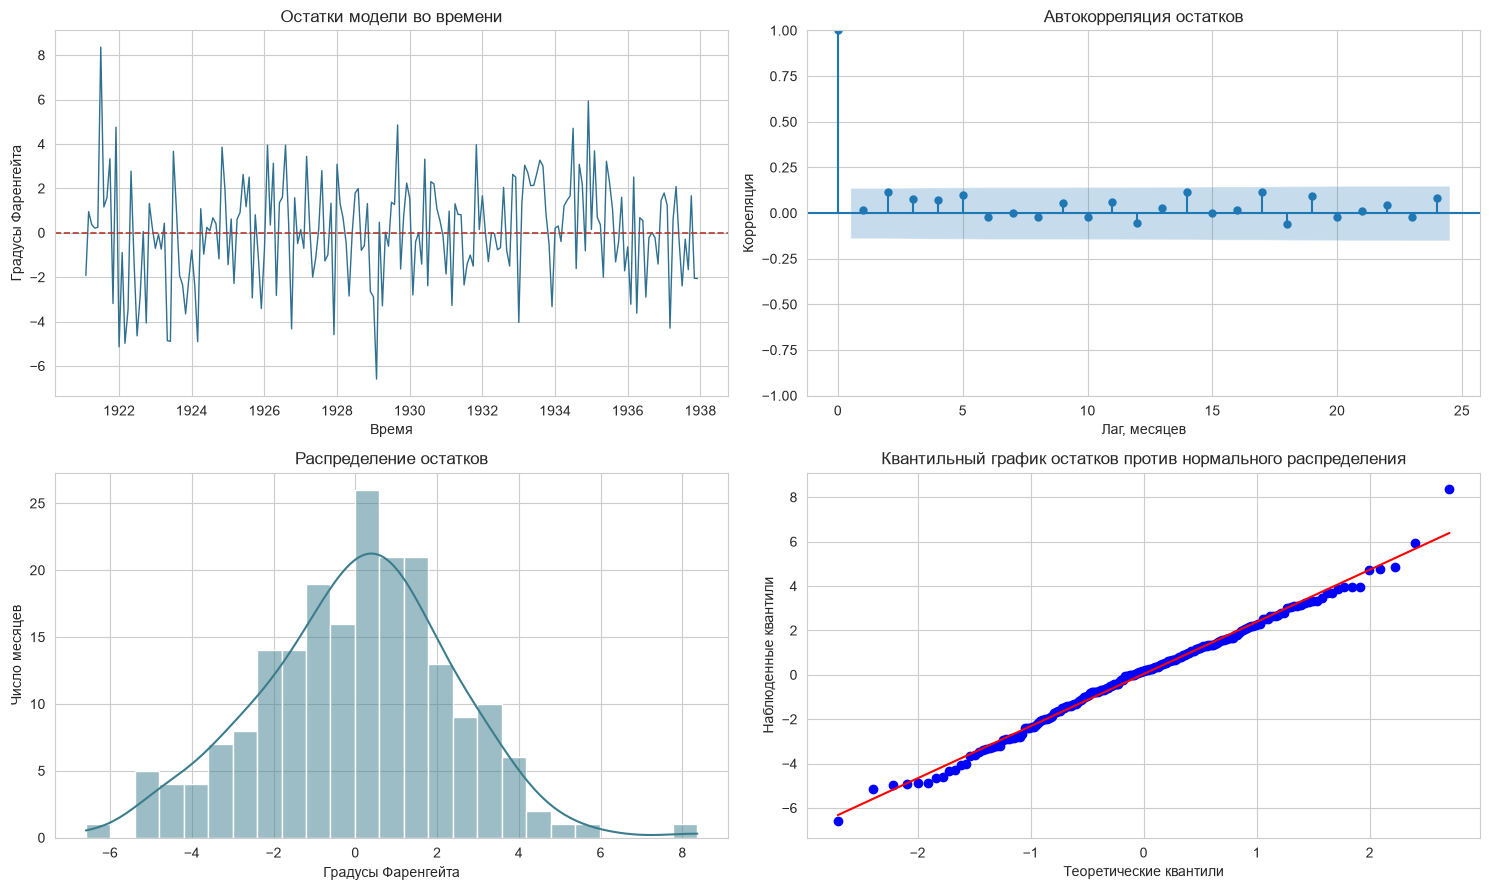

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(остатки.index, остатки.values, color='#2f6f8f', linewidth=1.0)
axes[0, 0].axhline(0, color='#b03a2e', linestyle='--', linewidth=1.2)
axes[0, 0].set_title('Остатки модели во времени')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Градусы Фаренгейта')

plot_acf(остатки, lags=24, alpha=0.05, ax=axes[0, 1])
axes[0, 1].set_title('Автокорреляция остатков')
axes[0, 1].set_xlabel('Лаг, месяцев')
axes[0, 1].set_ylabel('Корреляция')

sns.histplot(остатки, bins=25, kde=True, color='#3b7d8c', ax=axes[1, 0])
axes[1, 0].set_title('Распределение остатков')
axes[1, 0].set_xlabel('Градусы Фаренгейта')
axes[1, 0].set_ylabel('Число месяцев')

stats.probplot(остатки, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Квантильный график остатков против нормального распределения')
axes[1, 1].set_xlabel('Теоретические квантили')
axes[1, 1].set_ylabel('Наблюденные квантили')

plt.tight_layout()
plt.show()

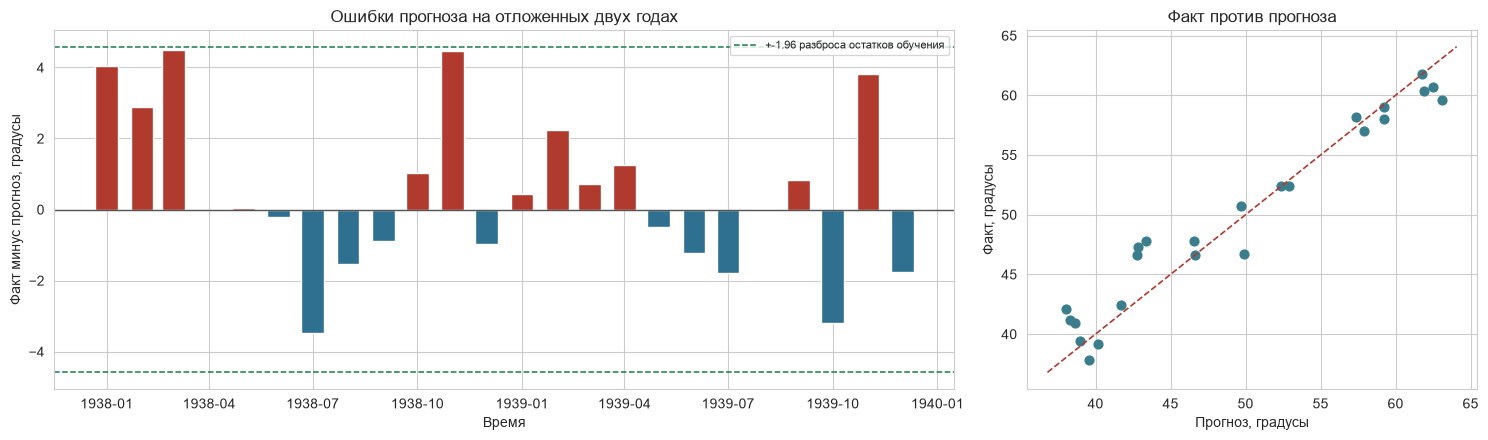

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), width_ratios=[2, 1])

цвета = ['#b03a2e' if о > 0 else '#2f6f8f' for о in ошибки]
axes[0].bar(тест.index, ошибки, width=20, color=цвета)
axes[0].axhline(0, color='#555555', linewidth=1.0)
axes[0].axhline(остатки.std(ddof=1) * 1.96, color='#1a7a4c', linestyle='--', linewidth=1.1,
                label='+-1.96 разброса остатков обучения')
axes[0].axhline(-остатки.std(ddof=1) * 1.96, color='#1a7a4c', linestyle='--', linewidth=1.1)
axes[0].set_title('Ошибки прогноза на отложенных двух годах')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Факт минус прогноз, градусы')
axes[0].legend(fontsize=8)

axes[1].scatter(прогноз24, тест.values, color='#3b7d8c', s=40)
пределы = [min(прогноз24.min(), тест.min()) - 1, max(прогноз24.max(), тест.max()) + 1]
axes[1].plot(пределы, пределы, color='#b03a2e', linestyle='--', linewidth=1.2)
axes[1].set_title('Факт против прогноза')
axes[1].set_xlabel('Прогноз, градусы')
axes[1].set_ylabel('Факт, градусы')

plt.tight_layout()
plt.show()

**Вывод по Задаче 6:**

**Остаток неотличим от белого шума, и это подтверждают все четыре проверки.**

*   **Автокорреляции нет ни на одном лаге.** Из 24 лагов за полосу **+-0.138** не выходит
    ни один. Критерий Льюнга-Бокса дает p-value **0.309** на шести лагах, **0.670**
    на двенадцати и **0.669** на двадцати четырех - оснований говорить о зависимости нет
    ни на коротких лагах, ни на сезонном.
*   **Распределение похоже на нормальное.** Критерий Шапиро-Уилка дает p-value **0.487**,
    асимметрия **-0.033**, эксцесс **0.334**. На квантильном графике точки ложатся на прямую,
    заметно отходя от нее только на самых краях.
*   **Разброс не меняется во времени, и это проверено методом интервалов.** По четвертям
    обучающей части он идет **2.759, 2.307, 1.999, 2.144**, критерий Левене дает p-value
    **0.348**. Среднее остатка **0.034** при общем разбросе **2.339**.

**Проверка на отложенном хвосте дает то же самое.** Разброс ошибок прогноза **2.267**
против **2.339** у остатков обучения - на новых данных модель не рассыпалась. Среднее
ошибки **0.447**, то есть оба года оказались чуть теплее предсказанного, но на фоне разброса
2.27 это меньше четверти сигмы. Самая большая промашка - **4.49 градуса в марте 1938 года**,
и она укладывается в полосу двух сигм остатков обучения.

Модель забрала из ряда все, что в нем было систематического. Оставшиеся 2.3 градуса разброса -
это погода, а не пропущенная закономерность

### Задача 7. Дополнительное задание: прогноз классическим ML на лагах

Задание предлагает попробовать обычные модели машинного обучения, подавая им прошлые значения
ряда как признаки. Прием прямой: строим таблицу, где столбцы - значения ряда на несколько
месяцев назад, и учим на ней регрессию.

Смысл эксперимента - в подборе набора лагов. Набор задает не только качество, но и **горизонт**:
если в признаках есть лаг 1, модель умеет предсказывать только следующий месяц, потому что
для более далекого прогноза этого значения еще нет. Набор, начинающийся с лага 24, умеет
предсказывать на два года вперед. Поэтому в таблице рядом с качеством стоит наименьший лаг -
это и есть горизонт, а сравнивать между собой честно только модели с одинаковым горизонтом.

Разделение на обучение и проверку то же, что и везде: граница по декабрю 1937 года

In [19]:
def лаговая(ряд, лаги):
    """таблица «значение ряда и его прошлые значения»: по столбцу на каждый лаг"""
    таблица = pd.DataFrame({'y': ряд})
    for л in лаги:
        таблица['лаг %d' % л] = ряд.shift(л)
    return таблица.dropna()


def обучить_и_проверить(лаги, модель):
    """обучение на месяцах до границы, проверка на отложенных - граница та же, что у ARIMA"""
    таблица = лаговая(ряд, лаги)
    учеба = таблица[таблица.index <= обуч.index[-1]]
    проверка_ = таблица[таблица.index > обуч.index[-1]]
    модель.fit(учеба.drop(columns='y'), учеба['y'])
    return модель, проверка_['y'], модель.predict(проверка_.drop(columns='y')), len(учеба)


наборы = [('лаг 12', [12]), ('лаги 1 и 12', [1, 12]), ('лаги 11-13', [11, 12, 13]),
          ('лаги 1-12', list(range(1, 13))), ('лаги 1-24', list(range(1, 25))),
          ('лаги 12-24', list(range(12, 25))), ('лаги 24-36', list(range(24, 37)))]

строки = []
for имя, лаги in наборы:
    _, факт, п_лр, сколько = обучить_и_проверить(лаги, LinearRegression())
    _, _, п_лес, _ = обучить_и_проверить(лаги, RandomForestRegressor(n_estimators=300, random_state=10))
    строки.append({'набор лагов': имя, 'признаков': len(лаги), 'горизонт': min(лаги),
                   'месяцев в обучении': сколько,
                   'регрессия RMSE': round(rmse(факт, п_лр), 3),
                   'регрессия MAE': round(mean_absolute_error(факт, п_лр), 3),
                   'лес RMSE': round(rmse(факт, п_лес), 3),
                   'лес MAE': round(mean_absolute_error(факт, п_лес), 3)})
print(pd.DataFrame(строки).to_string(index=False))

набор лагов  признаков  горизонт  месяцев в обучении  регрессия RMSE  регрессия MAE  лес RMSE  лес MAE
     лаг 12          1        12                 204           2.733          1.921     3.459    2.488
лаги 1 и 12          2         1                 204           2.637          1.855     2.888    2.181
 лаги 11-13          3        11                 203           2.336          1.675     2.983    2.276
  лаги 1-12         12         1                 204           2.530          2.023     2.534    1.818
  лаги 1-24         24         1                 192           2.459          1.873     2.879    2.142
 лаги 12-24         13        12                 192           2.226          1.698     3.012    2.190
 лаги 24-36         13        24                 180           2.360          1.786     2.478    1.963


In [20]:
лр, _, _, _ = обучить_и_проверить(list(range(1, 25)), LinearRegression())
лес, _, _, _ = обучить_и_проверить(list(range(1, 25)), RandomForestRegressor(n_estimators=300, random_state=10))
столбцы = ['лаг %d' % л for л in range(1, 25)]

веса = pd.Series(лр.coef_, index=столбцы).sort_values(key=abs, ascending=False)
важность = pd.Series(лес.feature_importances_, index=столбцы).sort_values(ascending=False)
print('линейная регрессия, свободный член %.2f, наибольшие по модулю коэффициенты:' % лр.intercept_)
print(веса.head(5).round(3).to_string())
print('\nслучайный лес, самые важные признаки:')
print(важность.head(5).round(3).to_string())
print('\nкорреляция ряда со своими лагами:',
      {л: round(обуч.corr(обуч.shift(л)), 3) for л in [1, 6, 12, 18, 24]})

линейная регрессия, свободный член 23.15, наибольшие по модулю коэффициенты:
лаг 1     0.347
лаг 24    0.282
лаг 13    0.138
лаг 11    0.118
лаг 20   -0.115

случайный лес, самые важные признаки:
лаг 18    0.590
лаг 12    0.148
лаг 6     0.114
лаг 24    0.091
лаг 1     0.005

корреляция ряда со своими лагами: {1: np.float64(0.814), 6: np.float64(-0.895), 12: np.float64(0.919), 18: np.float64(-0.897), 24: np.float64(0.944)}


In [21]:
# сравнение честно только при одинаковом горизонте: у ARIMA он задается длиной прогноза,
# у моделей на лагах - наименьшим лагом в наборе
_, факт1, лр1, _ = обучить_и_проверить(list(range(1, 25)), LinearRegression())
_, _, лес1, _ = обучить_и_проверить(list(range(1, 25)), RandomForestRegressor(n_estimators=300, random_state=10))
_, факт24, лр24, _ = обучить_и_проверить(list(range(24, 37)), LinearRegression())
_, _, лес24, _ = обучить_и_проверить(list(range(24, 37)), RandomForestRegressor(n_estimators=300, random_state=10))

сравнение = pd.DataFrame([
    {'горизонт': 'шаг вперед', 'SARIMA': round(rmse(тест, прогноз1), 3),
     'линейная регрессия на лагах': round(rmse(факт1, лр1), 3),
     'случайный лес на лагах': round(rmse(факт1, лес1), 3),
     'база: средний месяц': round(rmse(тест, по_профилю), 3)},
    {'горизонт': 'два года вперед', 'SARIMA': round(rmse(тест, прогноз24), 3),
     'линейная регрессия на лагах': round(rmse(факт24, лр24), 3),
     'случайный лес на лагах': round(rmse(факт24, лес24), 3),
     'база: средний месяц': round(rmse(тест, по_профилю), 3)}])
print('RMSE на отложенных двух годах:')
print(сравнение.to_string(index=False))

# самое простое объяснение проигрыша леса - что дерево отвечает средним по обучающим точкам
# и потому жмет предсказания к середине. Это проверяемо: сравним размахи
print('\nразмах предсказаний на наборе лагов 24-36:')
print('   факт %.1f, линейная регрессия %.1f, случайный лес %.1f'
      % (факт24.max() - факт24.min(), лр24.max() - лр24.min(), лес24.max() - лес24.min()))

RMSE на отложенных двух годах:
       горизонт  SARIMA  линейная регрессия на лагах  случайный лес на лагах  база: средний месяц
     шаг вперед   2.212                        2.459                   2.879                2.311
два года вперед   2.263                        2.360                   2.478                2.311

размах предсказаний на наборе лагов 24-36:
   факт 24.0, линейная регрессия 25.6, случайный лес 25.3


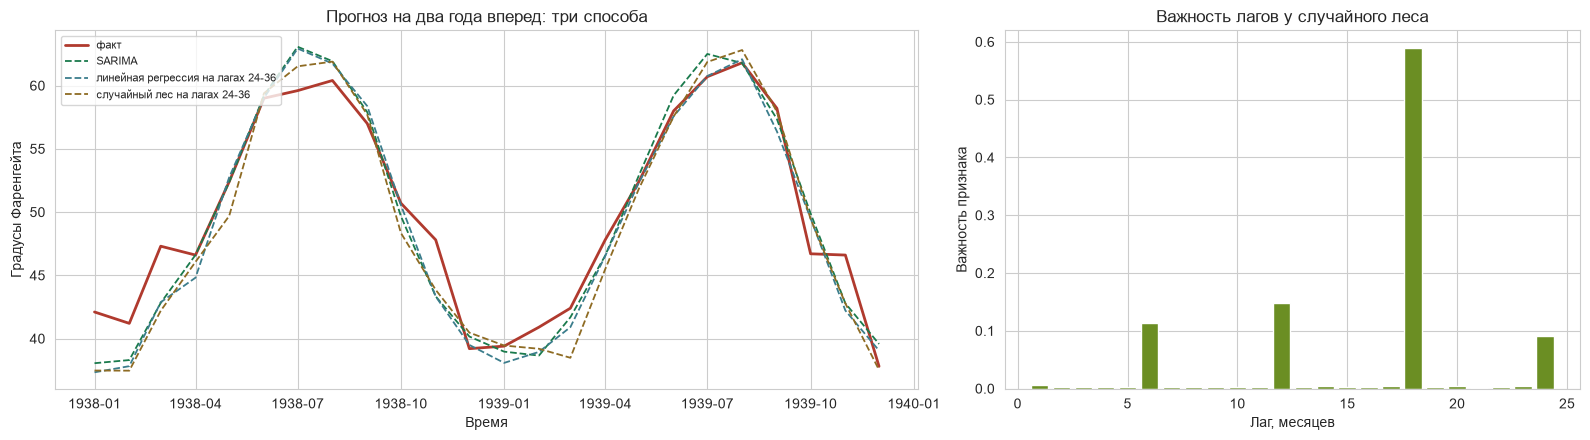

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), width_ratios=[3, 2])

axes[0].plot(тест.index, тест.values, color='#b03a2e', linewidth=2.0, label='факт')
axes[0].plot(тест.index, прогноз24, color='#1a7a4c', linewidth=1.3, linestyle='--', label='SARIMA')
axes[0].plot(факт24.index, лр24, color='#3b7d8c', linewidth=1.3, linestyle='--',
             label='линейная регрессия на лагах 24-36')
axes[0].plot(факт24.index, лес24, color='#8e6b23', linewidth=1.3, linestyle='--',
             label='случайный лес на лагах 24-36')
axes[0].set_title('Прогноз на два года вперед: три способа')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Градусы Фаренгейта')
axes[0].legend(loc='upper left', fontsize=8)

порядок_лагов = ['лаг %d' % л for л in range(1, 25)]
axes[1].bar(range(1, 25), важность[порядок_лагов].values, color='#6b8e23')
axes[1].set_title('Важность лагов у случайного леса')
axes[1].set_xlabel('Лаг, месяцев')
axes[1].set_ylabel('Важность признака')

plt.tight_layout()
plt.show()

**Вывод по Задаче 7:**

**Линейная регрессия на лагах - это и есть авторегрессия, записанная другими словами.**
Лучший ее результат, **2.226** на наборе лагов 12-24, стоит ровно там же, где результаты
сезонных ARIMA. Ничего удивительного: обе модели строят линейную комбинацию прошлых значений,
разница только в том, что ARIMA вдобавок моделирует собственные ошибки, а регрессия - нет.

**Случайный лес проигрывает везде,** от **2.478** до 3.459, и ни на одном наборе лагов
не обходит линейную регрессию. Простое объяснение - что дерево отвечает средним по обучающим
точкам и потому жмет предсказания к середине - замером **не подтверждается**: размах его
предсказаний на лагах 24-36 равен **25.3 градуса** против 24.0 у факта и 25.6 у регрессии,
то есть не сжат. Чем именно лес хуже на этих данных, из замеров не следует. Проверяемая
версия - слишком короткое обучение, 180-204 строки на 13 признаков; проверить ее можно,
сравнив качество при разной глубине дерева и на искусственно удлиненном ряде.

**Лес опирается на противофазный лаг, а регрессия - нет.** Важность признака у леса
**0.590** на лаге 18 против 0.148 на лаге 12, а корреляция ряда с лагом 18 равна **-0.897**:
восемнадцать месяцев назад - это ровно противофаза, июль против января. У линейной регрессии
лаг 18 в первую пятерку весов не входит вовсе, там главные - **0.347 на лаге 1** и **0.282
на лаге 24**. Разбиение по порогу одинаково работает и на прямой связи, и на обратной,
поэтому для леса противофазный лаг ничем не хуже синфазного.

**При одинаковом горизонте ARIMA впереди в обоих режимах:** на шаг вперед **2.212** против
2.459 у регрессии и 2.879 у леса, на два года - **2.263** против 2.360 и 2.478. Базу «средний
месяц» (2.311) обходит только SARIMA: регрессия на лагах не дотягивает до нее в обоих режимах

### Дополнительный эксперимент 1 (вне рамок задания). Чем описывать годовую волну

Сезонная разность - не единственный способ убрать сезонность, и у нее есть скрытое допущение.
Разность вида «этот январь минус прошлый январь» предполагает, что уровень января **сдвигается
и остается на новом месте**, то есть сезонность накопительная. Если же волна каждый год
повторяется примерно одинаково - сезонность **детерминированная**, - ее правильнее описать
явно: синусоидой с годовым периодом или двенадцатью средними.

В Задаче 2 замерено, что вычитание профиля дает вдвое меньший разброс, чем сезонная разность.
Проверим, во что это превращается в готовой модели. Гармоники Фурье и переменные-месяцы
подаются в ту же SARIMAX как внешние признаки, сезонная разность при этом не берется,
а порядок ARMA для каждого варианта подбирается своим перебором по AIC

In [23]:
def гармоники(индекс, K):
    """K пар синусов и косинусов с годовым периодом: чем больше K, тем точнее описывается
    форма волны и тем больше столбцов"""
    месяц = индекс.month.values
    столбцы = {}
    for k in range(1, K + 1):
        столбцы['sin %d' % k] = np.sin(2 * np.pi * k * месяц / 12)
        столбцы['cos %d' % k] = np.cos(2 * np.pi * k * месяц / 12)
    return pd.DataFrame(столбцы, index=индекс)


def месяцы_столбцами(индекс):
    return pd.get_dummies(индекс.month, prefix='месяц', drop_first=True).set_index(индекс).astype(float)


описания = [('гармоника Фурье, K=1', lambda и: гармоники(и, 1)),
            ('гармоники Фурье, K=2', lambda и: гармоники(и, 2)),
            ('гармоники Фурье, K=3', lambda и: гармоники(и, 3)),
            ('11 переменных-месяцев', месяцы_столбцами)]

строки, лучшие_экз = [], {}
for имя, построить in описания:
    признаки_обуч, признаки_тест = построить(обуч.index), построить(тест.index)
    рекорд = None
    for p in range(4):
        for q in range(4):
            try:
                м = подгонка(обуч, (p, 0, q), экз=признаки_обуч)
                if рекорд is None or м.aic < рекорд[0]:
                    рекорд = (м.aic, (p, q), м)
            except Exception:
                continue
    _, (p, q), м = рекорд
    прогноз = м.forecast(24, exog=признаки_тест)
    лучшие_экз[имя] = (м, прогноз.values, построить)
    строки.append({'описание сезонности': имя, 'столбцов': признаки_обуч.shape[1],
                   'порядок ARMA': '(%d, %d)' % (p, q), 'AIC': round(м.aic, 2), 'BIC': round(м.bic, 2),
                   'RMSE на 24 шага': round(rmse(тест, прогноз), 3),
                   'MAE на 24 шага': round(mean_absolute_error(тест, прогноз), 3)})

строки.append({'описание сезонности': 'сезонная разность, D=1', 'столбцов': 0,
               'порядок ARMA': '(2, 3)', 'AIC': round(лучшая.aic, 2), 'BIC': round(лучшая.bic, 2),
               'RMSE на 24 шага': round(rmse(тест, прогноз24), 3),
               'MAE на 24 шага': round(mean_absolute_error(тест, прогноз24), 3)})
print(pd.DataFrame(строки).to_string(index=False))

   описание сезонности  столбцов порядок ARMA    AIC     BIC  RMSE на 24 шага  MAE на 24 шага
  гармоника Фурье, K=1         2       (3, 2) 983.28 1013.65            2.114           1.566
  гармоники Фурье, K=2         4       (3, 2) 968.23 1005.35            2.136           1.599
  гармоники Фурье, K=3         6       (2, 3) 968.02 1011.90            2.152           1.555
 11 переменных-месяцев        11       (1, 0) 976.47 1023.72            2.359           1.723
сезонная разность, D=1         0       (2, 3) 933.73  960.28            2.263           1.744


двенадцать средних минус синусоида, по месяцам:
1     2.22
2     0.75
3    -0.06
4    -1.37
5    -0.95
6    -0.29
7     1.56
8     0.78
9     0.40
10   -0.77
11   -2.29
12    0.01
наибольшее расхождение 2.29 градуса (месяц 11), синусоида объясняет 0.979 разброса профиля


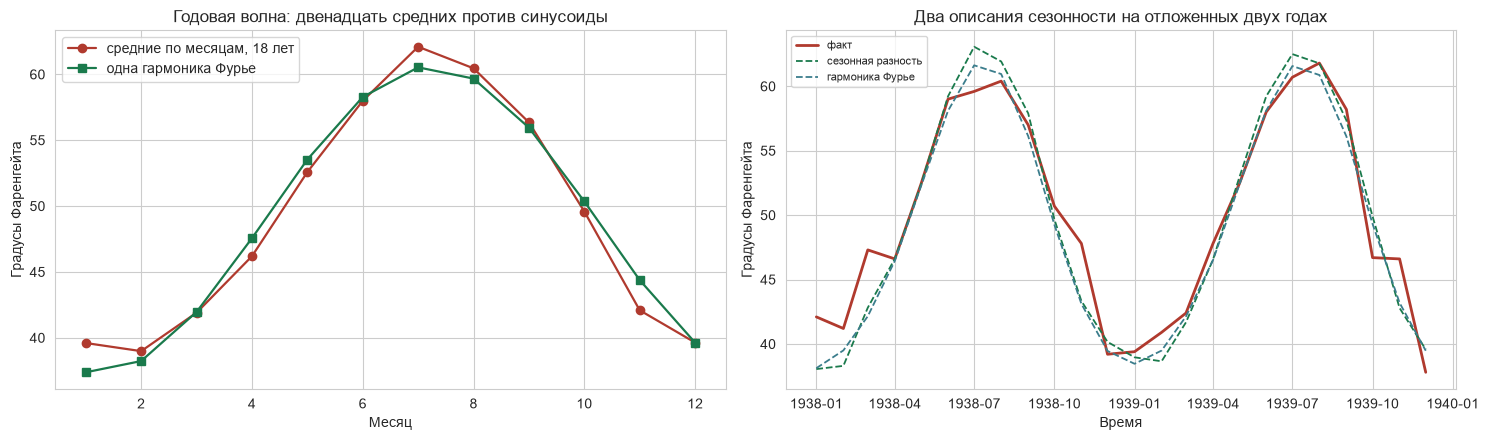

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# как выглядит годовая волна по версии одной синусоиды и по версии двенадцати средних.
# синусоида подгоняется отдельным МНК, а не собирается из коэффициентов SARIMAX: там
# при trend='c' свободный член входит в авторегрессионную рекурсию, и уровень волны
# оказался бы ниже фактического - среднее ряда равно intercept / (1 - сумма коэффициентов AR)
_, прогноз_гарм, _ = лучшие_экз['гармоника Фурье, K=1']
сетка_месяцев = pd.date_range('1938-01-01', periods=12, freq='MS')
синусоида = (LinearRegression().fit(гармоники(обуч.index, 1), обуч.values)
             .predict(гармоники(сетка_месяцев, 1)))
расхождение = pd.Series(профиль.values - синусоида, index=range(1, 13))
print('двенадцать средних минус синусоида, по месяцам:')
print(расхождение.round(2).to_string())
print('наибольшее расхождение %.2f градуса (месяц %d), синусоида объясняет %.3f разброса профиля'
      % (расхождение.abs().max(), расхождение.abs().idxmax(),
         1 - расхождение.var(ddof=0) / профиль.var(ddof=0)))

axes[0].plot(range(1, 13), профиль.values, marker='o', color='#b03a2e', linewidth=1.6,
             label='средние по месяцам, 18 лет')
axes[0].plot(range(1, 13), синусоида, marker='s', color='#1a7a4c', linewidth=1.6,
             label='одна гармоника Фурье')
axes[0].set_title('Годовая волна: двенадцать средних против синусоиды')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Градусы Фаренгейта')
axes[0].legend()

axes[1].plot(тест.index, тест.values, color='#b03a2e', linewidth=2.0, label='факт')
axes[1].plot(тест.index, прогноз24, color='#1a7a4c', linewidth=1.3, linestyle='--',
             label='сезонная разность')
axes[1].plot(тест.index, прогноз_гарм, color='#3b7d8c', linewidth=1.3, linestyle='--',
             label='гармоника Фурье')
axes[1].set_title('Два описания сезонности на отложенных двух годах')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Градусы Фаренгейта')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

**Вывод по дополнительному эксперименту 1:**

**Два критерия отвечают по-разному, и это главное наблюдение раздела.** По AIC сезонная
разность выигрывает с большим запасом: **933.73** против **968-983** у всех вариантов
с явным описанием волны. А на отложенном хвосте порядок обратный: одна гармоника Фурье дает
RMSE **2.114** против **2.263** у сезонной разности.

Противоречия здесь нет. AIC меряет, насколько хорошо модель описывает уже виденное, и
сезонная разность в этом сильнее: она подстраивается под уровень каждого года. Прогноз
на два года вперед меряет другое, и там подстройка под конкретный год ничего не дает.

**Одной синусоиды достаточно.** Два столбца дают **2.114**, шесть столбцов - 2.152,
одиннадцать переменных-месяцев - **2.359**, то есть худший результат из четырех.

Годовой ход температуры действительно почти синусоида: подогнанная синусоида объясняет
**97.9%** разброса двенадцати средних. Расходятся они на краях осени и зимы - **-2.29
градуса в ноябре** и **+2.22 в январе**: настоящий ноябрь холоднее, чем предписывает синус,
а настоящий январь мягче. Двенадцать отдельных средних дают гибкость описать и это,
но платят одиннадцатью оцененными параметрами вместо двух, и на прогнозе гибкость
не окупается.

Разница между лучшим и худшим вариантом - **0.245 градуса** на 24 месяцах. По масштабу
это то же самое, что бутстрэп-интервал из Задачи 5, **[-0.387, 0.379]**

### Дополнительный эксперимент 2 (вне рамок задания). Держится ли порядок моделей

Все сравнения выше сделаны на одном отрезке из 24 месяцев, и Задача 5 уже показала, чего
такой замер стоит: интервал разности RMSE между моделью и простым правилом накрывает ноль.
Значит, и порядок моделей между собой мог сложиться случайно.

Проверить это можно скользящим началом: взять каждый год с 1930-го по 1939-й, обучить модели
на всем, что было **до** него, и спрогнозировать двенадцать месяцев вперед. Получится десять
независимых замеров вместо одного.

Оговорка про чистоту опыта: порядки моделей подбирались по данным до конца 1937 года, поэтому
для восьми лет из десяти данные, на которых порядок выбирался, частично те же. Полностью
новыми остаются только 1938 и 1939 годы

In [25]:
скользящее = []
for год in range(1930, 1940):
    граница = pd.Timestamp('%d-12-01' % (год - 1))
    учеба = ряд[ряд.index <= граница]
    проверка_ = ряд[(ряд.index > граница) & (ряд.index <= pd.Timestamp('%d-12-01' % год))]
    строка = {'прогноз на год': год, 'месяцев в обучении': len(учеба)}
    for имя, порядок, сезонный in [('SARIMA(2,0,3)(0,1,2,12)', (2, 0, 3), (0, 1, 2, 12)),
                                   ('SARIMA(1,0,0)(0,1,1,12)', (1, 0, 0), (0, 1, 1, 12))]:
        м = подгонка(учеба, порядок, сезонный)
        строка[имя] = round(rmse(проверка_, м.forecast(len(проверка_))), 3)
    м = подгонка(учеба, (3, 0, 2), экз=гармоники(учеба.index, 1))
    строка['гармоника и ARMA(3,2)'] = round(
        rmse(проверка_, м.forecast(len(проверка_), exog=гармоники(проверка_.index, 1))), 3)
    строка['база: средний месяц'] = round(
        rmse(проверка_, учеба.groupby(учеба.index.month).mean().loc[проверка_.index.month].values), 3)
    скользящее.append(строка)

скользящее = pd.DataFrame(скользящее)
столбцы_моделей = [с for с in скользящее.columns if с not in ('прогноз на год', 'месяцев в обучении')]
print(скользящее.to_string(index=False))
print('\nсреднее RMSE по десяти годам:')
print(скользящее[столбцы_моделей].mean().round(3).sort_values().to_string())
print('\nсколько раз каждая была лучшей из четырех:')
print(скользящее[столбцы_моделей].idxmin(axis=1).value_counts().to_string())

 прогноз на год  месяцев в обучении  SARIMA(2,0,3)(0,1,2,12)  SARIMA(1,0,0)(0,1,1,12)  гармоника и ARMA(3,2)  база: средний месяц
           1930                 120                    1.962                    1.755                  1.764                1.783
           1931                 132                    2.284                    2.195                  1.988                2.232
           1932                 144                    1.361                    1.858                  1.735                1.962
           1933                 156                    3.070                    3.230                  3.184                3.218
           1934                 168                    2.665                    2.615                  2.810                2.653
           1935                 180                    1.918                    2.242                  2.027                2.455
           1936                 192                    1.939                    1.887     

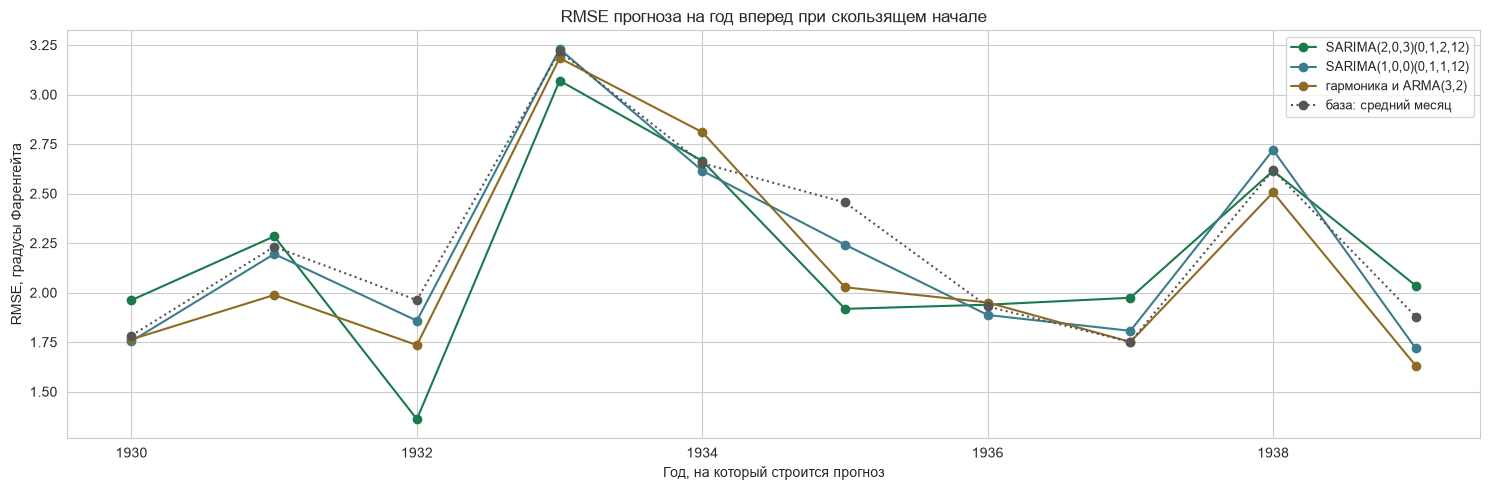

In [26]:
plt.figure(figsize=(15, 5))
for столбец, цвет in zip(столбцы_моделей, ['#1a7a4c', '#3b7d8c', '#8e6b23', '#555555']):
    стиль = ':' if столбец.startswith('база') else '-'
    plt.plot(скользящее['прогноз на год'], скользящее[столбец], marker='o',
             linewidth=1.5, linestyle=стиль, color=цвет, label=столбец)
plt.title('RMSE прогноза на год вперед при скользящем начале')
plt.xlabel('Год, на который строится прогноз')
plt.ylabel('RMSE, градусы Фаренгейта')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Вывод по дополнительному эксперименту 2:**

**Разброс между годами в шестнадцать раз больше разброса между моделями.** По десяти годам
RMSE гуляет от **1.361** до **3.230**, размах **1.869**. Средние по десяти замерам стоят
вплотную: **2.135** у гармоники, **2.182** и **2.203** у двух сезонных ARIMA, **2.248**
у среднего месяца, - между лучшей и худшей **0.113 градуса**. От года зависит на порядок
больше, чем от выбора модели.

**Порядок моделей от года к году не держится.** Гармоника оказывается лучшей в четырех годах
из десяти, каждая из двух ARIMA - в трех. Средний месяц не выигрывает ни разу, но в 1937 году
делит первое место с гармоникой - у обеих 1.751.

**Годы, которые дались всем одинаково плохо, - общие.** В 1933-м все четыре способа дают
от 3.07 до 3.23, в 1934-м - от 2.62 до 2.81. Это не свойство модели, а свойство года: погода
в нем отклонилась от обычной сильнее, чем в среднем, и предсказать это по прошлым годам
было нечем.

**Вывод раздела совпадает с выводом Задачи 5, но опирается уже на десять замеров, а не
на один:** на этом ряде выбор между сезонной ARIMA, гармоникой и средним месяцем меняет
точность в пределах десятой доли градуса. Единственное, что дает заметный выигрыш, - наличие
сезонной части вообще: несезонная ARIMA(3,0,2) отставала от всех на четверть градуса